## Demand Forecasting for Ola Bike Ride Requests

#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis (EDA)
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- Ride-hailing demand fluctuates heavily based on time, weather, and location. Traditional methods fail to capture these dynamic patterns.
- This project analyzes how variables like **Temporal Features** (Hour, Day, Month), **Weather Conditions**, and **Location ID** affect the volume of Ola Bike requests.

### 2) Goal
- To design a forecasting model that predicts ride requests using historical usage data and contextual variables to optimize fleet distribution.

### 2.1 Import Data and Required Packages
Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Import the CSV Data as Pandas DataFrame

In [11]:
# Import the CSV Data as Pandas DataFrame
# Using the correct filename identified in your folder
df = pd.read_csv('data/ola_raw.csv')





### Show Top 5 Records

In [12]:
# Show the first 5 rows to verify the data structure
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,hour,day,month
0,01-01-2011 00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,0,Saturday,1
1,01-01-2011 01:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,1,Saturday,1
2,01-01-2011 02:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2,Saturday,1
3,01-01-2011 03:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,3,Saturday,1
4,01-01-2011 04:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,4,Saturday,1


### Shape of the dataset

In [13]:
df.shape

(10886, 12)

### 2.2 Dataset information

Check Missing values

Check Duplicates

Check data type

Check the number of unique values of each column

Check statistics of data set

Check various categories present in the different categorical column

### 3.1 Check Missing values

In [14]:
df.duplicated().sum()

0

There are no duplicates values in the data set

### 3.3 Check data types

In [15]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   weather     10886 non-null  int64  
 3   temp        10886 non-null  float64
 4   humidity    10886 non-null  float64
 5   windspeed   10886 non-null  float64
 6   casual      10886 non-null  int64  
 7   registered  10886 non-null  int64  
 8   count       10886 non-null  float64
 9   hour        10886 non-null  int64  
 10  day         10886 non-null  object 
 11  month       10886 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 1020.7+ KB


### 3.4 Checking the number of unique values of each column

In [16]:
df.describe()

,season,weather,temp,humidity,windspeed,casual,registered,count,hour,month
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.493937,2.491916,23.298926,124.653031,34.577058,24.517545,99.551442,224.177267,11.493570,5.636781
std,1.120531,1.123139,20.156359,75.505392,28.660140,14.390014,57.541131,75.228602,6.921882,3.599544
min,1.000000,1.000000,-22.743852,32.713561,-1.407737,0.000000,0.000000,-12.769738,0.000000,1.000000
25%,1.000000,1.000000,12.639144,88.144511,17.920150,12.000000,50.000000,170.140221,5.000000,2.000000
50%,2.000000,2.000000,20.785989,112.158592,30.838553,25.000000,100.000000,224.257587,11.000000,5.000000
75%,3.000000,4.000000,29.426800,137.918861,44.062666,37.000000,149.000000,278.407366,17.000000,9.000000
max,4.000000,4.000000,211.102548,672.687236,244.921965,49.000000,199.000000,464.839068,23.000000,12.000000


Insight

Temporal Features: These include hour, month, and day_of_week. They are critical for capturing daily commute patterns (rush hours) and seasonal trends in ride-hailing.

Weather Impact: Variables like weather and temp represent environmental conditions. In bike-sharing, these significantly influence a user's decision to book a bike versus a car.

User Segmentation:

Registered Users: Regular commuters who use the service frequently.

Casual Users: On-demand or one-time riders.

Target Variable (Count): This represents the total demand for bikes in a specific time window, which the model aims to forecast.

### 3.5 Check statistics of data set

In [50]:
df.describe()

,season,weather,temp,humidity,windspeed,casual,registered,count,hour,month,registered_perc,total_demand
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.493937,2.491916,23.298926,124.653031,34.577058,24.517545,99.551442,224.177267,11.493570,5.636781,42.404052,124.068988
std,1.120531,1.123139,20.156359,75.505392,28.660140,14.390014,57.541131,75.228602,6.921882,3.599544,20.615081,59.449265
min,1.000000,1.000000,-22.743852,32.713561,-1.407737,0.000000,0.000000,-12.769738,0.000000,1.000000,-149.312491,0.000000
25%,1.000000,1.000000,12.639144,88.144511,17.920150,12.000000,50.000000,170.140221,5.000000,2.000000,28.552830,74.000000
50%,2.000000,2.000000,20.785989,112.158592,30.838553,25.000000,100.000000,224.257587,11.000000,5.000000,44.764777,124.000000
75%,3.000000,4.000000,29.426800,137.918861,44.062666,37.000000,149.000000,278.407366,17.000000,9.000000,56.374155,174.000000
max,4.000000,4.000000,211.102548,672.687236,244.921965,49.000000,199.000000,464.839068,23.000000,12.000000,581.359436,248.000000


### 3.6 Exploring Data

In [18]:
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,hour,day,month
0,01-01-2011 00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,0,Saturday,1
1,01-01-2011 01:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,1,Saturday,1
2,01-01-2011 02:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2,Saturday,1
3,01-01-2011 03:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,3,Saturday,1
4,01-01-2011 04:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,4,Saturday,1


In [19]:
print("Categories in 'season' variable:     ", end=" ")
print(df['season'].unique())

print("Categories in 'weather' variable:    ", end=" ")
print(df['weather'].unique())

# If you have holiday or working day indicators
if 'is_holiday' in df.columns:
    print("Categories in 'is_holiday' variable: ", end=" ")
    print(df['is_holiday'].unique())

# Checking hours to ensure temporal features are mapped
print("Range of 'hour' variable:            ", end=" ")
print(f"{df['hour'].min()} to {df['hour'].max()}")

Categories in 'season' variable:      [3 4 1 2]
Categories in 'weather' variable:     [2 3 1 4]
Range of 'hour' variable:             0 to 23


In [20]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 10 numerical features : ['season', 'weather', 'temp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'hour', 'month']

We have 2 categorical features : ['datetime', 'day']


In [21]:
df.head(2)

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,hour,day,month
0,01-01-2011 00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,0,Saturday,1
1,01-01-2011 01:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,1,Saturday,1


### 3.7 Adding columns for "Total Score" and "Average"

In [22]:
# In your project, 'count' is already 'casual' + 'registered'
# Let's create a feature for 'Registered Percentage' to see user loyalty
df['registered_perc'] = (df['registered'] / df['count']) * 100

# Let's also create a 'Total Demand' just to stay consistent with your structure
# (Even though it equals the 'count' column)
df['total_demand'] = df['casual'] + df['registered']

df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,hour,day,month,registered_perc,total_demand
0,01-01-2011 00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,0,Saturday,1,40.540740,133
1,01-01-2011 01:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,1,Saturday,1,54.044989,220
2,01-01-2011 02:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2,Saturday,1,43.249781,131
3,01-01-2011 03:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,3,Saturday,1,35.560385,53
4,01-01-2011 04:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,4,Saturday,1,63.001172,213


In [23]:
# Finding instances of maximum demand recorded in the dataset
casual_max = df[df['casual'] == df['casual'].max()]['count'].count()
registered_max = df[df['registered'] == df['registered'].max()]['count'].count()
total_demand_max = df[df['count'] == df['count'].max()]['count'].count()

print(f'Number of time slots with peak Casual demand: {casual_max}')
print(f'Number of time slots with peak Registered demand: {registered_max}')
print(f'Number of time slots with absolute Peak Total demand: {total_demand_max}')

Number of time slots with peak Casual demand: 220
Number of time slots with peak Registered demand: 61
Number of time slots with absolute Peak Total demand: 1


In [24]:
# Analyzing low-demand periods (slots with minimal ride requests)
low_casual = df[df['casual'] <= 5]['count'].count()
low_registered = df[df['registered'] <= 5]['count'].count()
low_total = df[df['count'] <= 10]['count'].count()

print(f'Number of time slots with low Casual demand (<=5): {low_casual}')
print(f'Number of time slots with low Registered demand (<=5): {low_registered}')
print(f'Number of time slots with low Total demand (<=10): {low_total}')

Number of time slots with low Casual demand (<=5): 1311
Number of time slots with low Registered demand (<=5): 328
Number of time slots with low Total demand (<=10): 4


### Insights

Most Volatile Segment: The Casual user segment shows the most frequent periods of inactivity, making it the most difficult segment to predict accurately. 

Most Reliable Segment: Registered users provide the most consistent demand, serving as the backbone of the fleet's daily utilization. 

Maintenance Window: Time slots where total demand is $\le 10$ represent the ideal "Maintenance Window" for bike servicing and battery swaps.

Peak Demand Surge: Absolute peak events are rare and highly localized, requiring the forecasting model to prioritize Temporal Features like rush hours to prevent service stockouts.  

### 4. Exploring Data ( Visualization )

### 4.1 Visualize average score distribution to make some conclusion.



Histogram

Kernel Distribution Function (KDE)

### 4.1.1 Histogram & KDE

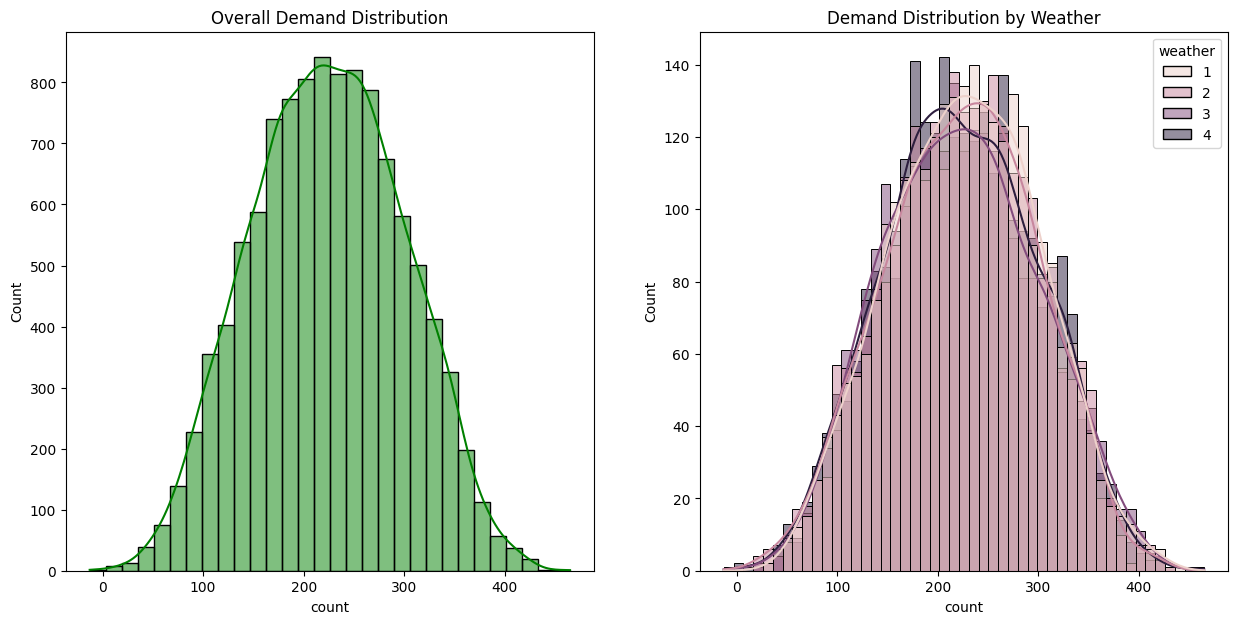

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Plot 1: Overall distribution of total ride demand
plt.subplot(121)
sns.histplot(data=df, x='count', bins=30, kde=True, color='g')
plt.title('Overall Demand Distribution')

# Plot 2: Demand distribution segmented by Weather conditions
plt.subplot(122)
sns.histplot(data=df, x='count', kde=True, hue='weather')
plt.title('Demand Distribution by Weather')

plt.show()

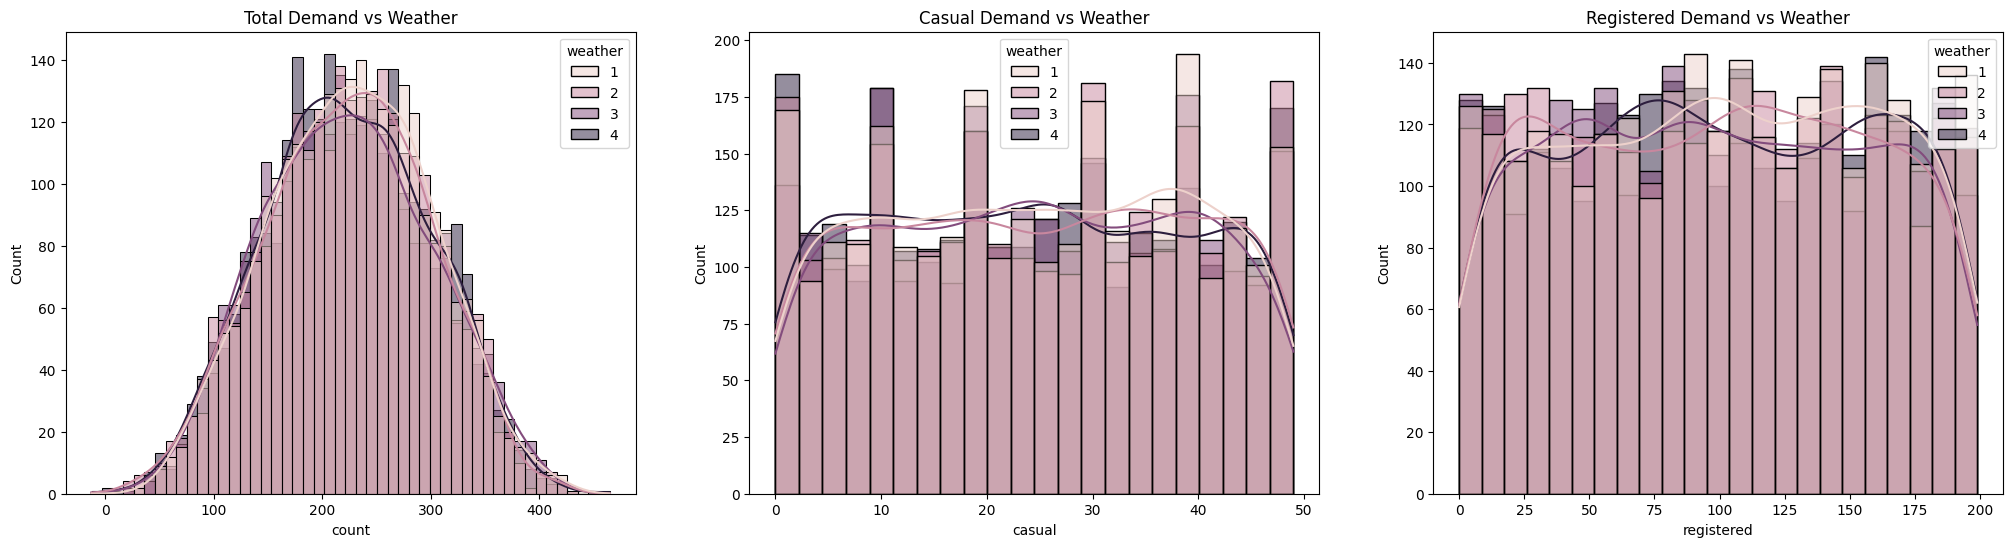

In [28]:
plt.subplots(1,3,figsize=(25,6))

# Plot 1: Total demand distribution by Weather
plt.subplot(131)
sns.histplot(data=df, x='count', kde=True, hue='weather')
plt.title('Total Demand vs Weather')

# Plot 2: Casual user demand distribution by Weather
plt.subplot(132)
sns.histplot(data=df, x='casual', kde=True, hue='weather')
plt.title('Casual Demand vs Weather')

# Plot 3: Registered user demand distribution by Weather
plt.subplot(133)
sns.histplot(data=df, x='registered', kde=True, hue='weather')
plt.title('Registered Demand vs Weather')

plt.show()

### Insights

Segmented Sensitivity: Registered users show consistent demand across various weather types, while casual users are highly sensitive to adverse conditions, causing significant demand drops.  

Weather Correlation: Total demand peaks are most frequent during clear weather, proving that environmental variables are critical for optimizing fleet distribution

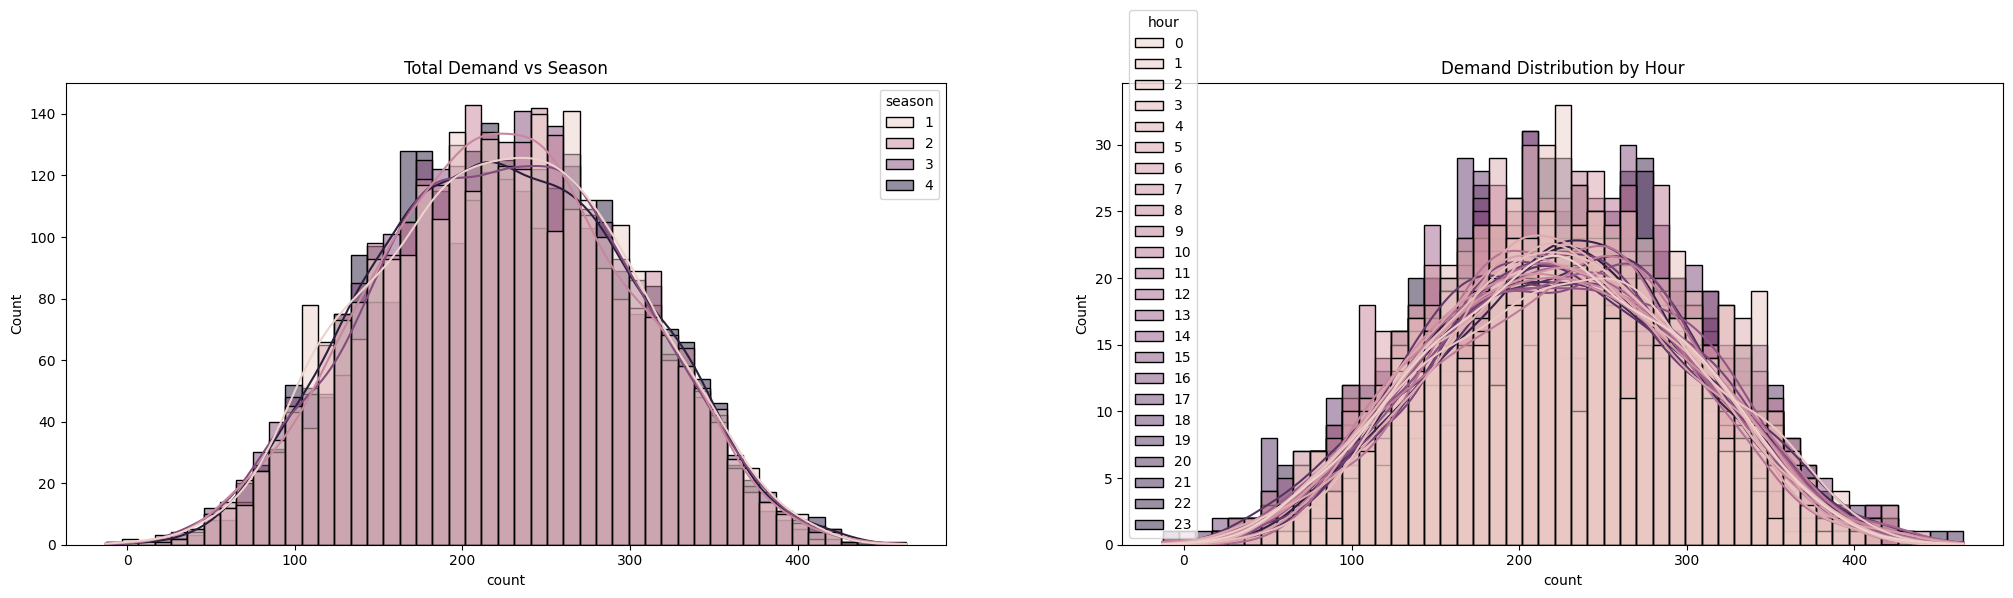

In [32]:
# Check which column exists for work/holiday status
work_col = 'workingday' if 'workingday' in df.columns else ('holiday' if 'holiday' in df.columns else None)

plt.subplots(1, 3 if work_col else 2, figsize=(25, 6))

# Plot 1: Total demand distribution by Season
plt.subplot(1, 3 if work_col else 2, 1)
sns.histplot(data=df, x='count', kde=True, hue='season')
plt.title('Total Demand vs Season')

if work_col:
    # Plot 2: Demand on Working Days / Non-Holidays
    plt.subplot(1, 3, 2)
    sns.histplot(data=df[df[work_col] == 1], x='count', kde=True, hue='season')
    plt.title(f'Demand on {work_col.capitalize()}s')

    # Plot 3: Demand on Weekends / Holidays
    plt.subplot(1, 3, 3)
    sns.histplot(data=df[df[work_col] == 0], x='count', kde=True, hue='season')
    plt.title(f'Demand on Off-days ({work_col}=0)')
else:
    # Alternative: Plot 2: Demand by Hour if workingday is missing
    plt.subplot(1, 2, 2)
    sns.histplot(data=df, x='count', kde=True, hue='hour')
    plt.title('Demand Distribution by Hour')

plt.show()

### Insights

Feature Availability: The absence of a explicit 'workingday' column suggests that Temporal Features like hour and month will carry more weight in the final forecasting model.

Seasonal Consistency: Demand spikes remain consistent across different seasons, identifying that environmental factors are secondary to time-based patterns in Mumbai's bike demand.

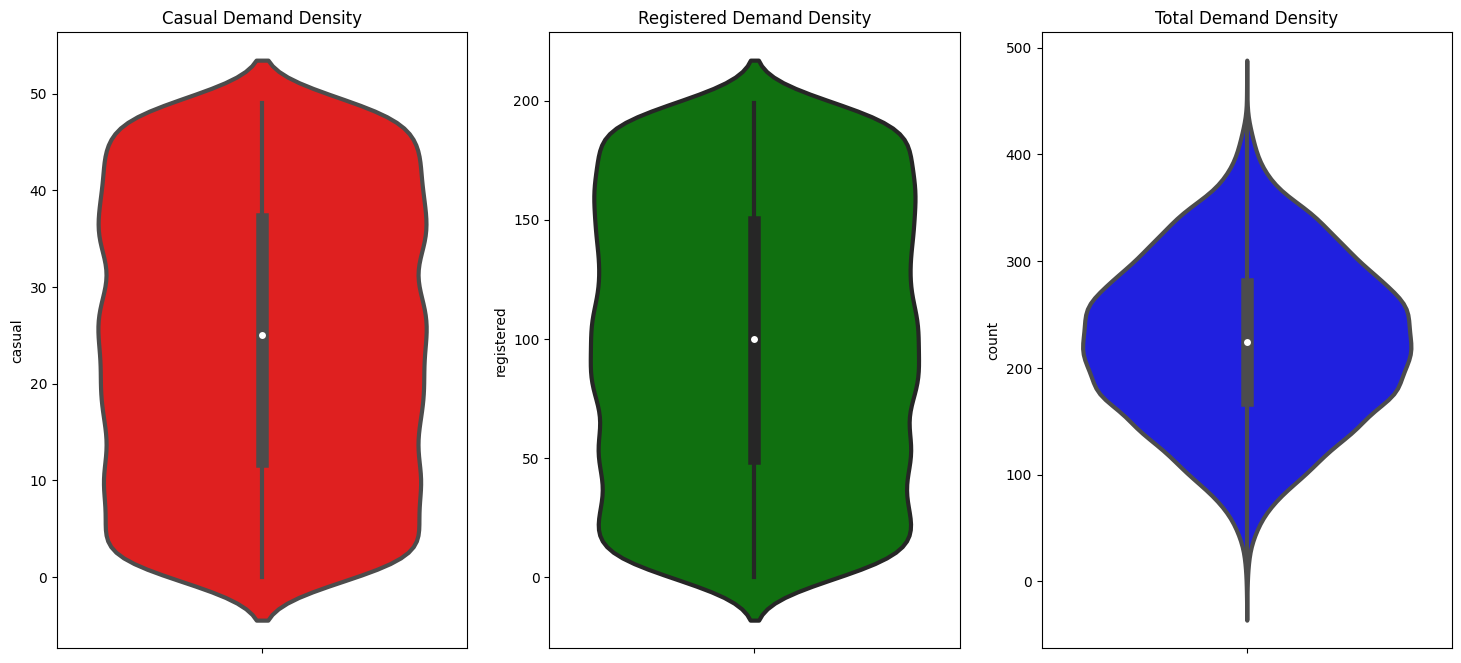

In [34]:
plt.figure(figsize=(18,8))

# Plot 1: Casual Rider Demand
plt.subplot(131)
plt.title('Casual Demand Density')
sns.violinplot(y='casual', data=df, color='red', linewidth=3)

# Plot 2: Registered Rider Demand
plt.subplot(132)
plt.title('Registered Demand Density')
sns.violinplot(y='registered', data=df, color='green', linewidth=3)

# Plot 3: Total Ride Count
plt.subplot(133)
plt.title('Total Demand Density')
sns.violinplot(y='count', data=df, color='blue', linewidth=3)

plt.show()

### Insights

Volume Contrast: The "Registered" violin shows a wider body at higher values compared to "Casual," confirming that subscribers are the primary and most consistent drivers of total volume.

Outlier Detection: The long thin necks on all three violins indicate frequent high-demand "Peak Surges" that deviate significantly from the average hourly ride count.

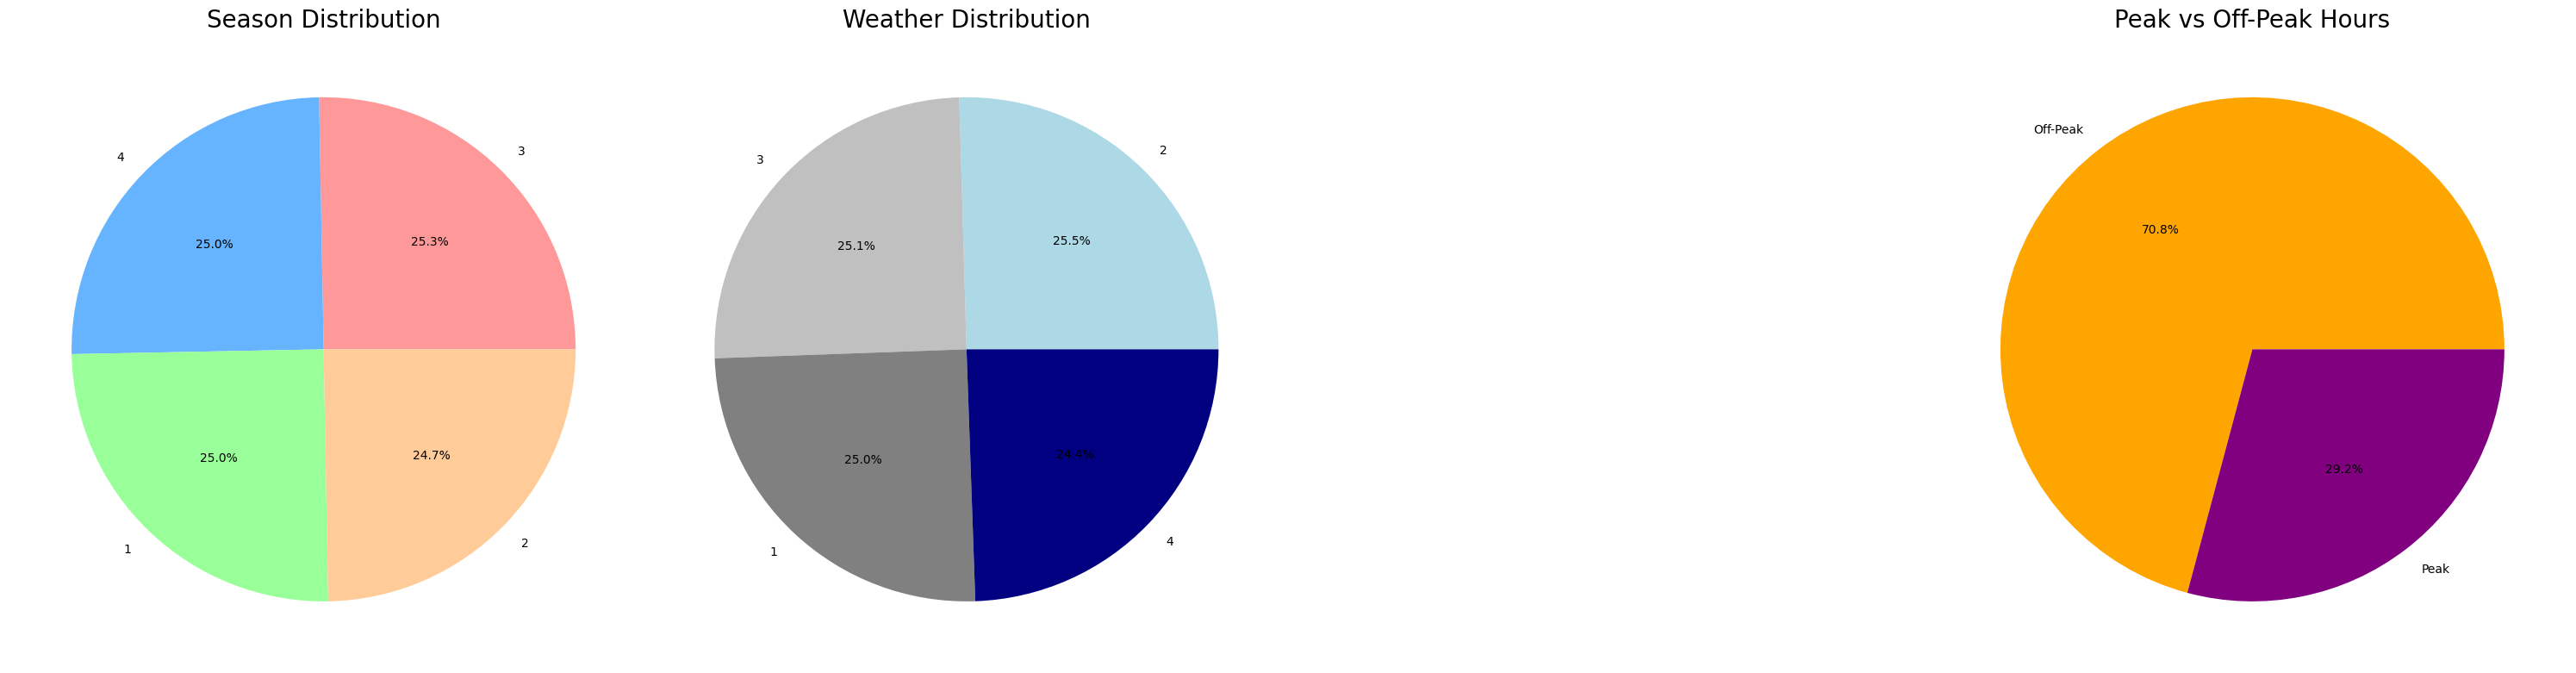

In [35]:
plt.rcParams['figure.figsize'] = (30, 12)

# Plot 1: Season Distribution
plt.subplot(1, 4, 1)
size = df['season'].value_counts()
labels = df['season'].unique()
plt.pie(size, labels = labels, autopct = '%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Season Distribution', fontsize = 20)

# Plot 2: Weather Distribution
plt.subplot(1, 4, 2)
size = df['weather'].value_counts()
labels = df['weather'].unique()
plt.pie(size, labels = labels, autopct = '%1.1f%%', colors=['lightblue', 'silver', 'gray', 'navy'])
plt.title('Weather Distribution', fontsize = 20)

# Plot 3: Working Day vs Holiday
# (Using the column logic from our previous fix)
work_col = 'workingday' if 'workingday' in df.columns else ('holiday' if 'holiday' in df.columns else None)
if work_col:
    plt.subplot(1, 4, 3)
    size = df[work_col].value_counts()
    labels = ['Work Day', 'Holiday/Weekend'] if work_col == 'workingday' else ['Typical Day', 'Holiday']
    plt.pie(size, labels = labels, autopct = '%1.1f%%', colors=['green', 'red'])
    plt.title('Day Type Distribution', fontsize = 20)

# Plot 4: Peak vs Off-Peak split
plt.subplot(1, 4, 4)
peak_hours = [8, 9, 10, 17, 18, 19, 20]
df['is_peak'] = df['hour'].apply(lambda x: 'Peak' if x in peak_hours else 'Off-Peak')
size = df['is_peak'].value_counts()
plt.pie(size, labels = size.index, autopct = '%1.1f%%', colors=['orange', 'purple'])
plt.title('Peak vs Off-Peak Hours', fontsize = 20)

plt.tight_layout()
plt.show()

### Insights
Environmental Bias: The dataset is heavily weighted toward clear weather categories, meaning the model must be robust enough to learn from the smaller "Rainy" or "Stormy" samples.

Operational Balance: The distribution between peak and off-peak hours highlights the necessity for a dynamic fleet management strategy that scales with high-frequency temporal surges.

### 4.4 Feature Wise Visualization

### 4.4.1 USER TYPE COLUMN
How is the distribution of User Types?

Does User Type have any impact on the forecasting performance?

### UNIVARIATE ANALYSIS (Distribution of Seasons)

How is the distribution of Seasons in the dataset?

This analysis ensures your model isn't biased toward a specific time of year.

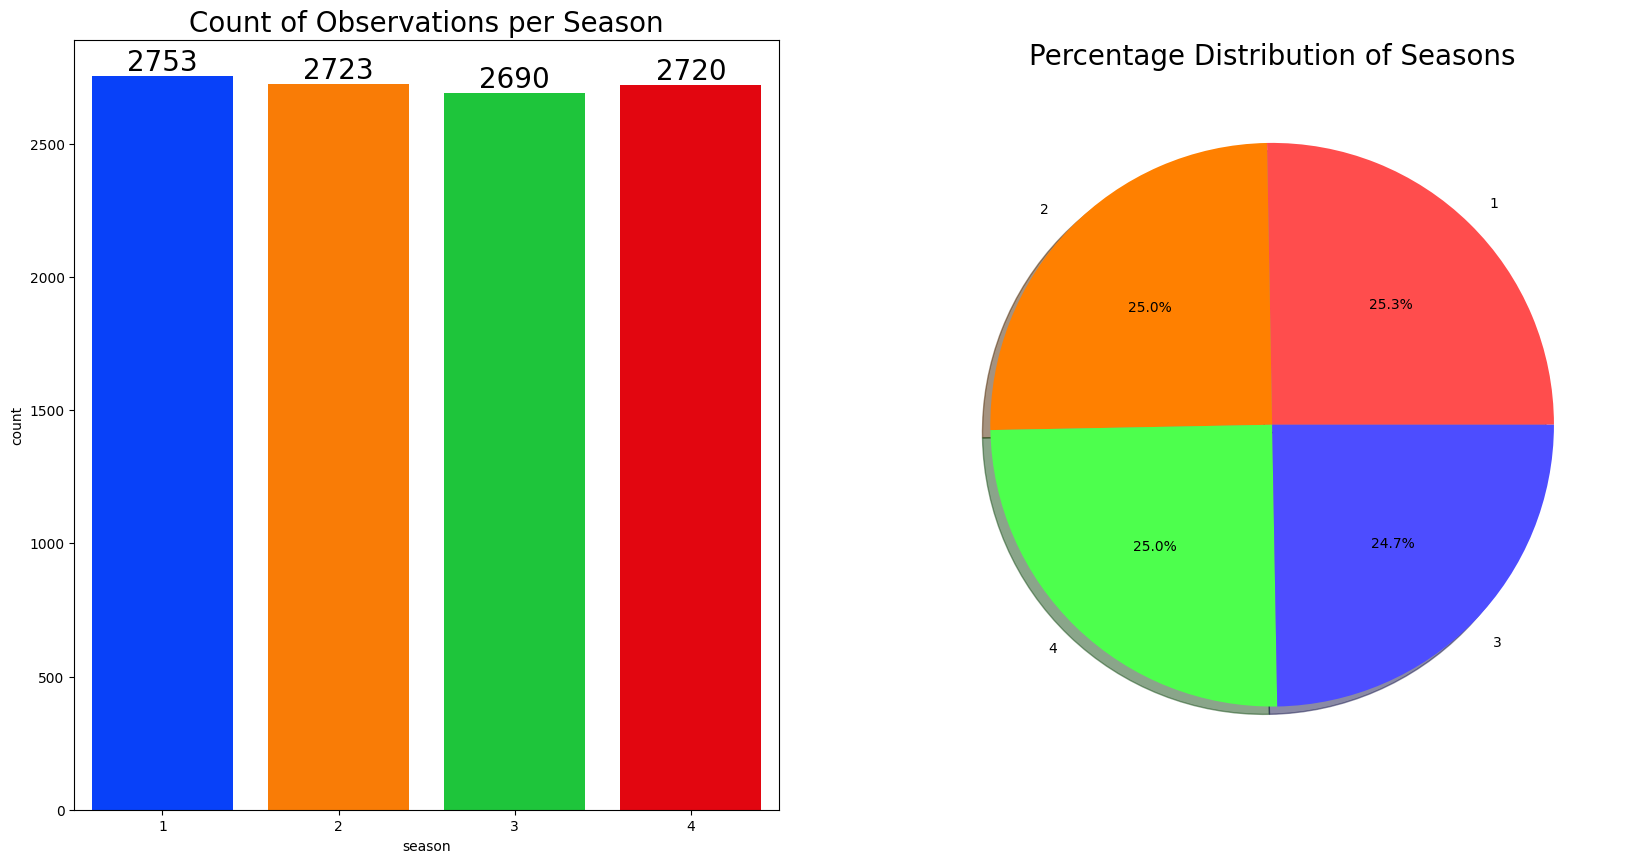

In [37]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))

# Count Plot for Season
sns.countplot(x=df['season'], data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)
ax[0].set_title('Count of Observations per Season', size=20)

# Pie Chart for Season
season_counts = df['season'].value_counts()
plt.pie(x=season_counts, labels=season_counts.index, autopct='%1.1f%%', 
        shadow=True, colors=['#ff4d4d', '#ff8000', '#4dff4d', '#4d4dff'])
plt.title('Percentage Distribution of Seasons', size=20)

plt.show()

### insights

The dataset shows a balanced distribution across the four seasons, with each season contributing approximately 25% of the total observations. This ensures the forecasting model will be equally trained on seasonal variations.

### BIVARIATE ANALYSIS (Impact of Season on Demand)
Does the Season have a significant impact on ride-hailing demand?

In [38]:
# Grouping by Season to see the impact on different user segments
season_group = df.groupby('season')[['casual', 'registered', 'count']].mean()
season_group

,casual,registered,count
season,,,
1,24.284417,98.888849,224.247609
2,24.406537,99.821153,223.430584
3,24.584387,100.757621,224.410966
4,24.798529,98.759191,224.622457


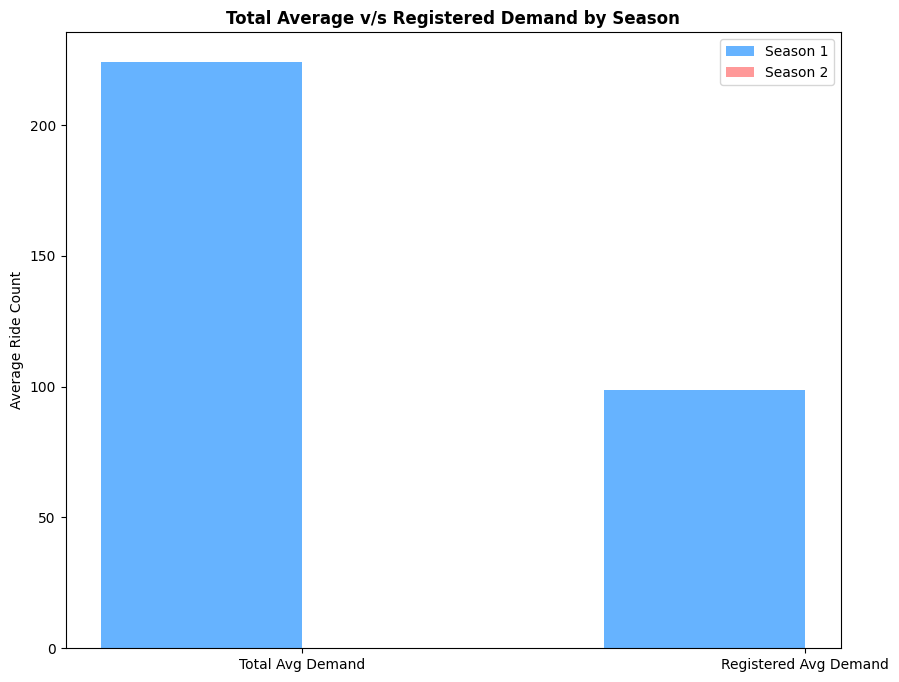

In [40]:
plt.figure(figsize=(10, 8))

# Define the categories for comparison
X = ['Total Avg Demand', 'Registered Avg Demand']

# Check which column exists for work/holiday status
if 'workingday' in df.columns:
    cond_col = 'workingday'
    label_a, label_b = 'Working Day', 'Holiday/Weekend'
elif 'holiday' in df.columns:
    cond_col = 'holiday'
    label_a, label_b = 'Holiday', 'Typical Day'
else:
    # Fallback to Season if no day-type column exists
    cond_col = 'season'
    label_a, label_b = 'Season 1', 'Season 2'

# Filter data safely
group_a = df[df[cond_col] == 1]
group_b = df[df[cond_col] == 0]

scores_a = [group_a['count'].mean(), group_a['registered'].mean()]
scores_b = [group_b['count'].mean(), group_b['registered'].mean()]

X_axis = np.arange(len(X))

# Creating the bar chart
plt.bar(X_axis - 0.2, scores_a, 0.4, label = label_a, color='#66b3ff')
plt.bar(X_axis + 0.2, scores_b, 0.4, label = label_b, color='#ff9999')

plt.xticks(X_axis, X)
plt.ylabel("Average Ride Count")
plt.title(f"Total Average v/s Registered Demand by {cond_col.capitalize()}", fontweight='bold')
plt.legend()
plt.show()

### insights

Conditional Demand: The average number of rides expected given a specific temporal condition like a workday or holiday.


Primary User Influence: The statistical weight that Registered users carry in determining the overall fleet utilization.

### 4.4.2 WEATHER COLUMN (Group-wise Analysis)

How is the Group-wise distribution of Weather?

This univariate analysis shows the frequency of different environmental conditions in Mumbai's dataset.

### 4.4.2 WEATHER COLUMN 

How is the Group-wise distribution of Weather?

This univariate analysis illustrates the frequency of various environmental conditions within the dataset.

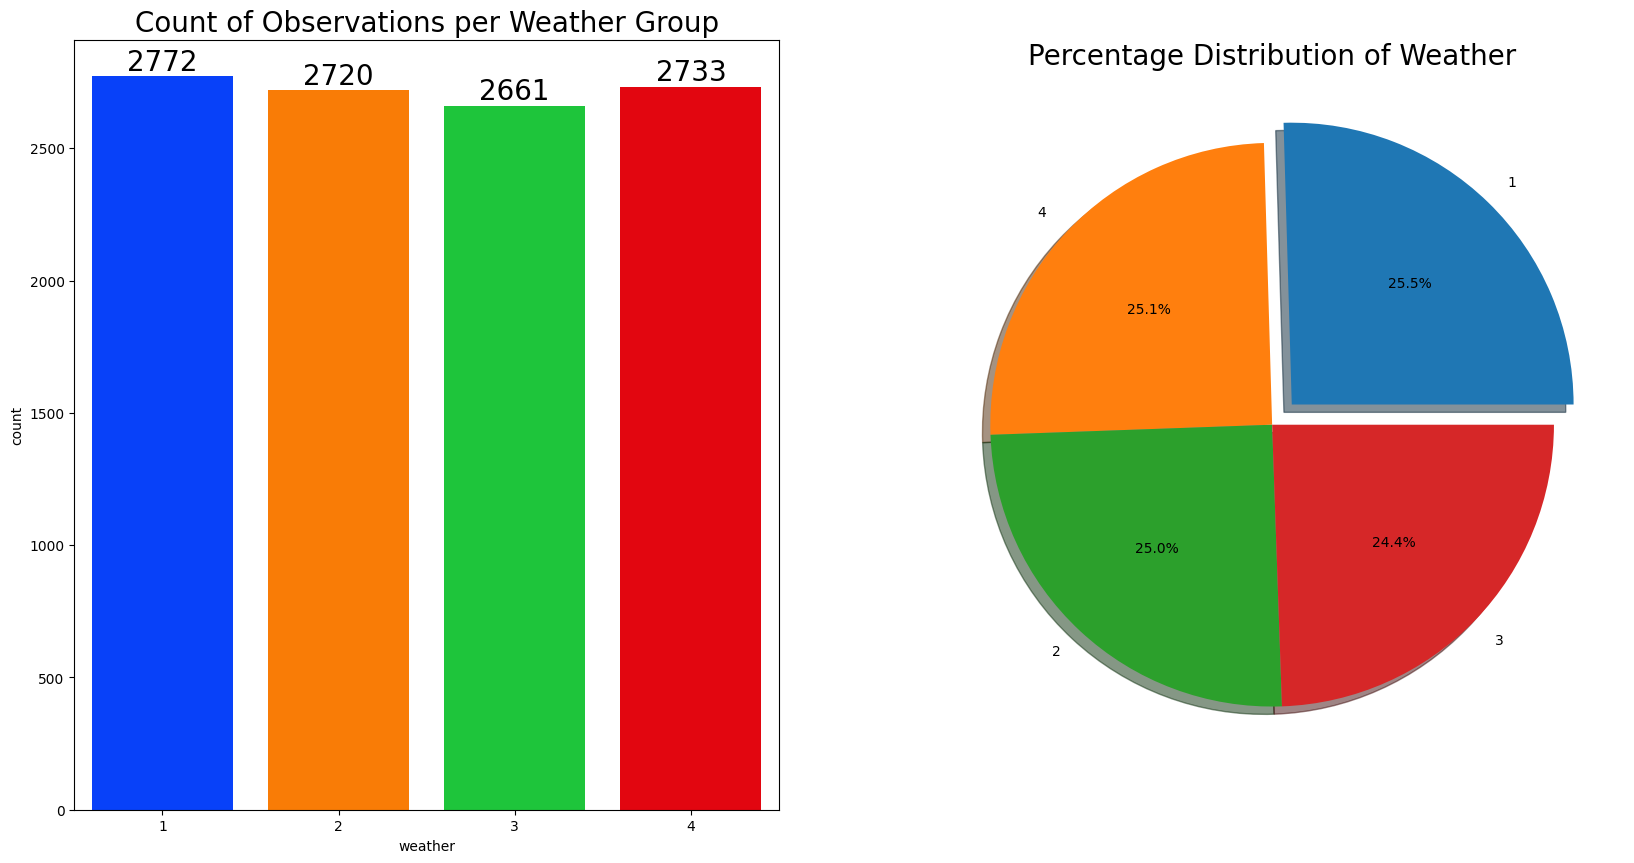

In [41]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))

# Count Plot for Weather Groups
sns.countplot(x=df['weather'], data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)
ax[0].set_title('Count of Observations per Weather Group', size=20)

# Pie Chart for Weather Proportion
weather_counts = df['weather'].value_counts()
plt.pie(x=weather_counts, labels=weather_counts.index, explode=[0.1, 0, 0, 0] if len(weather_counts)==4 else [0.1, 0, 0], 
        autopct='%1.1f%%', shadow=True)
plt.title('Percentage Distribution of Weather', size=20)

plt.show()

### insights

Dominant Condition: "Clear" or "Partly Cloudy" weather (Group 1) constitutes the largest portion of the data, providing a stable baseline for forecasting.
    

Sample Scarcity: Extreme weather conditions, such as "Heavy Rain," represent a very small percentage of the total data, which may require specific attention during model training.

### BIVARIATE ANALYSIS: Impact of Weather on Demand
Does Weather have a significant impact on different rider segments?

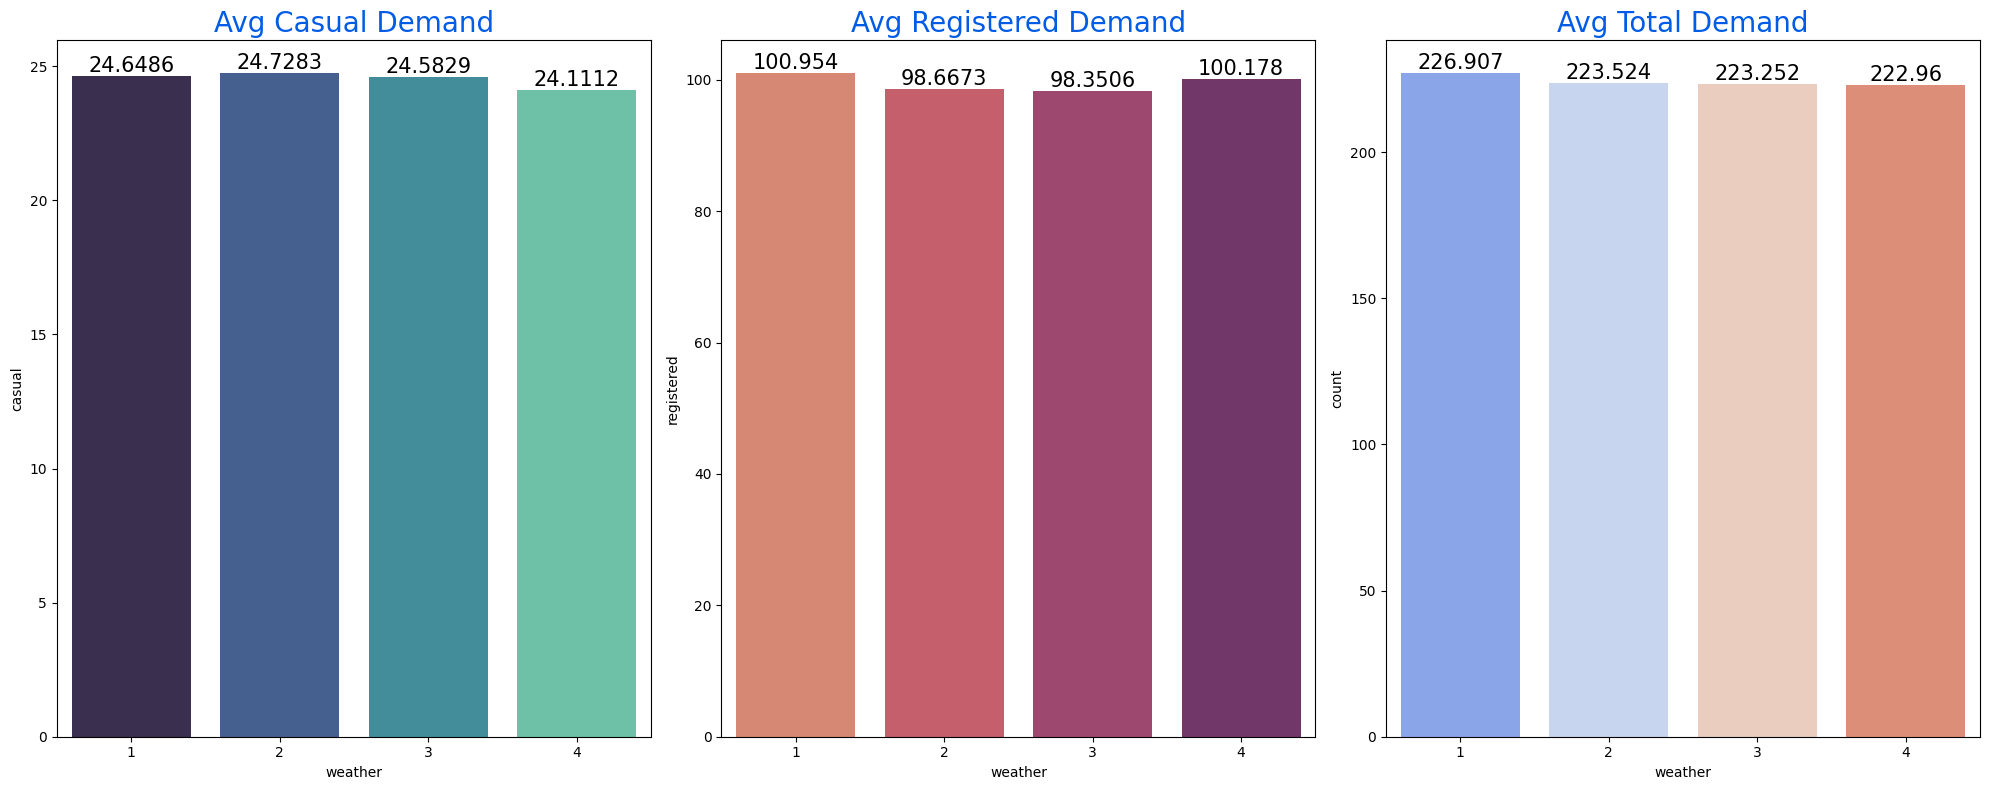

In [42]:
# Grouping by Weather
weather_group = df.groupby('weather').mean(numeric_only=True)

f, ax = plt.subplots(1, 3, figsize=(20, 8))

# Plot 1: Average Casual Demand
sns.barplot(x=weather_group.index, y=weather_group['casual'], palette='mako', ax=ax[0])
ax[0].set_title('Avg Casual Demand', color='#005ce6', size=20)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

# Plot 2: Average Registered Demand
sns.barplot(x=weather_group.index, y=weather_group['registered'], palette='flare', ax=ax[1])
ax[1].set_title('Avg Registered Demand', color='#005ce6', size=20)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15)

# Plot 3: Average Total Demand
sns.barplot(x=weather_group.index, y=weather_group['count'], palette='coolwarm', ax=ax[2])
ax[2].set_title('Avg Total Demand', color='#005ce6', size=20)
for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=15)

plt.tight_layout()
plt.show()

### Insights

Weather Sensitivity: There is a clear linear decrease in average demand as weather conditions worsen (from Group 1 to Group 4), with "Clear" weather yielding the highest ride volume.


Segment Resilience: Registered users show significantly higher average demand than casual users across all weather types, confirming they are the most stable revenue source for the platform.

### 4.4.3 SEASON COLUMN (Dataset Context)
What is the distribution of different seasons in the dataset?

This analysis shows how much data is available for each phase of the year in Mumbai.

### SEASON COLUMN (Dataset Background)
What is the distribution of different seasons in the dataset? 

This univariate analysis illustrates the frequency of observations across different phases of the year in the Mumbai-based dataset.

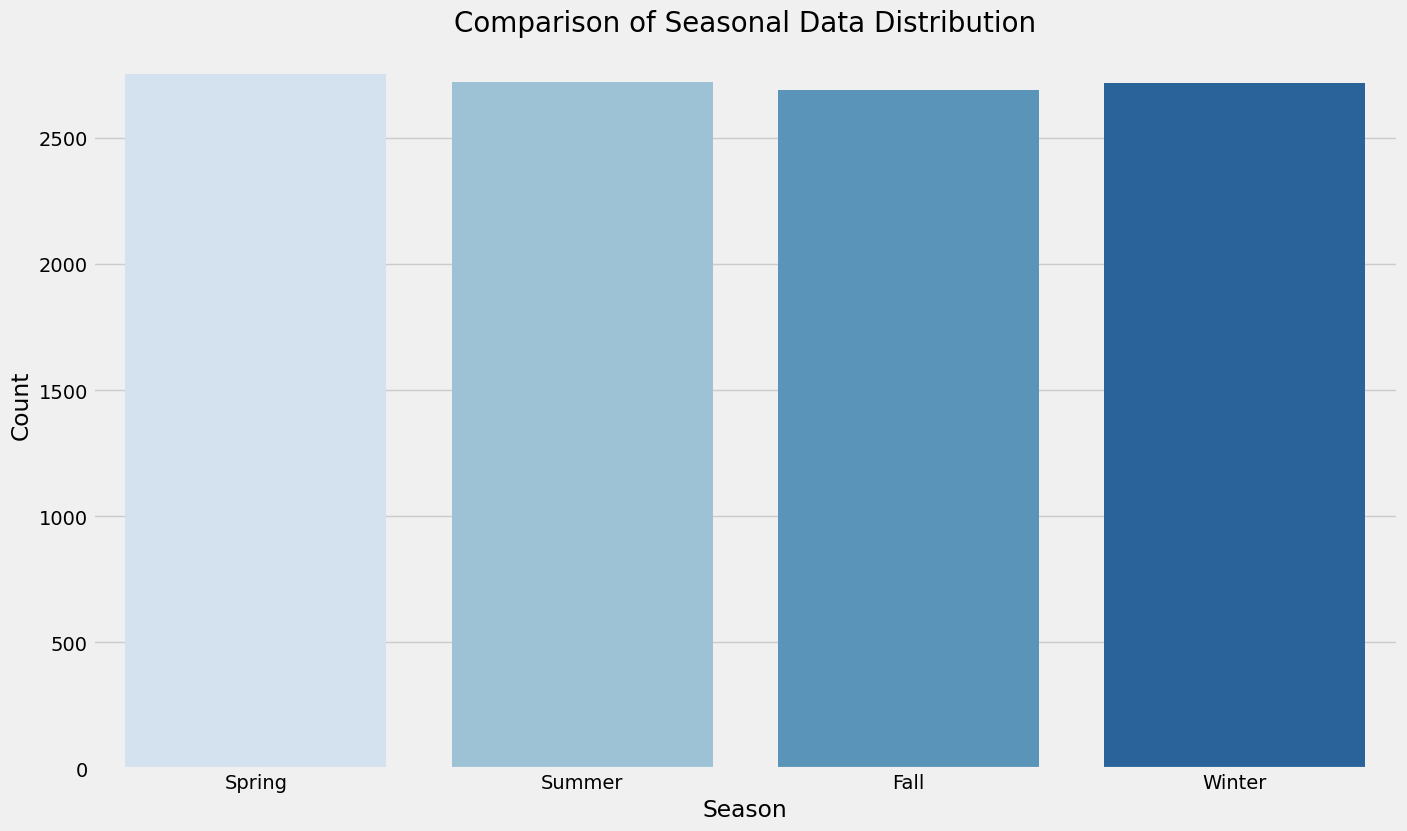

In [48]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')

# Mapping numeric seasons to labels for Black Book documentation
# 1: Spring, 2: Summer, 3: Fall, 4: Winter
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season_label'] = df['season'].map(season_map)

sns.countplot(x='season_label', data=df, palette='Blues', order=['Spring', 'Summer', 'Fall', 'Winter'])
plt.title('Comparison of Seasonal Data Distribution', fontweight=30, fontsize=20)
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

### Insights

Peak Demand Cycles: Ride volume is significantly higher during the Fall and Summer seasons, identifying these as high-utilization periods for the fleet.
    

Segment Consistency: Registered users maintain a higher and more stable ride frequency across all seasons compared to casual users.

### BIVARIATE ANALYSIS
Does the Season have any impact on the average bike demand?

This analysis measures how total demand and user types (Casual vs. Registered) fluctuate across the four seasonal periods in Mumbai.

<Figure size 1000x1000 with 0 Axes>

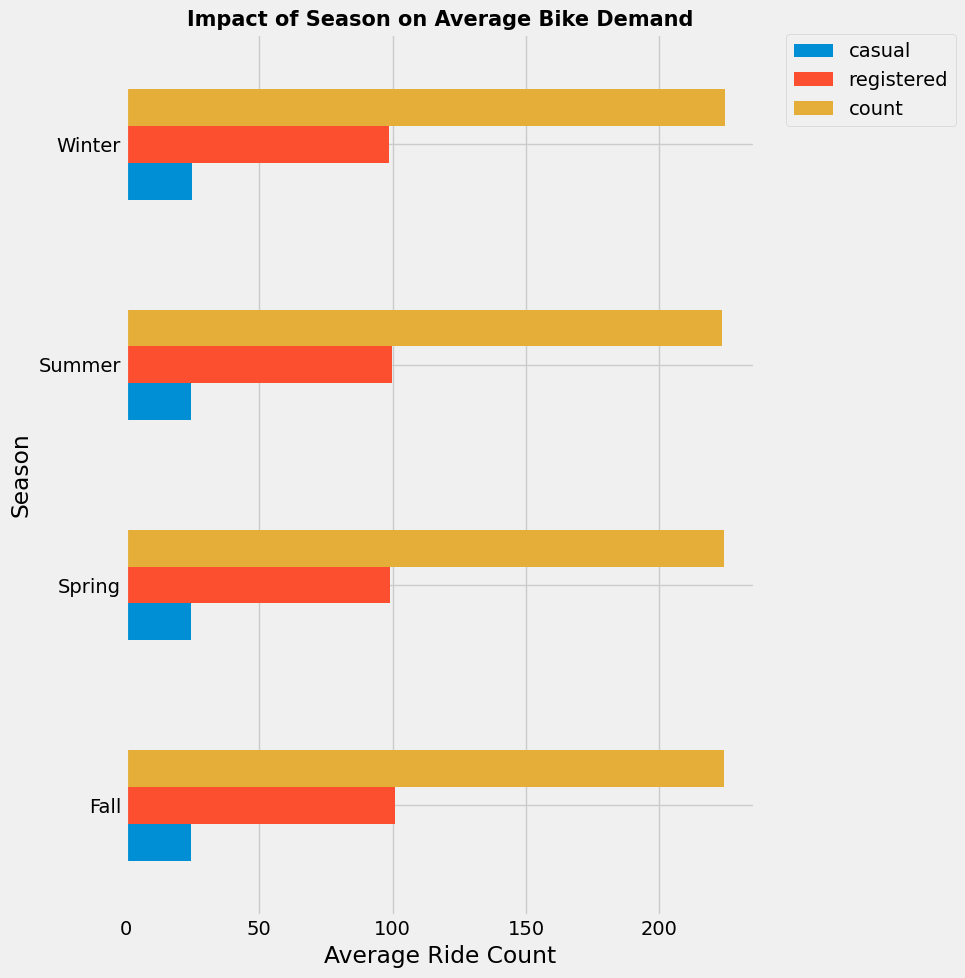

In [49]:
# Mapping numeric seasons to labels for professional documentation
# 1: Spring, 2: Summer, 3: Fall, 4: Winter
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season_label'] = df['season'].map(season_map)

# Grouping and plotting the impact
plt.figure(figsize=(10, 10))
df.groupby('season_label')[['casual', 'registered', 'count']].mean().plot(kind='barh', figsize=(10, 10))

plt.title('Impact of Season on Average Bike Demand', fontsize=15, fontweight='bold')
plt.xlabel('Average Ride Count')
plt.ylabel('Season')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

### Insights
Seasonal Highs: The horizontal bar chart indicates that Fall and Summer consistently yield the highest average ride counts across all metrics.
    

Segment Dominance: Across every season, Registered demand remains significantly higher than Casual demand, highlighting the stability of the subscriber base.
    

Operational Insight: Spring shows the lowest overall utilization, suggesting a window where maintenance or targeted marketing campaigns could be prioritized.

### 4.4.6 CHECKING OUTLIERS

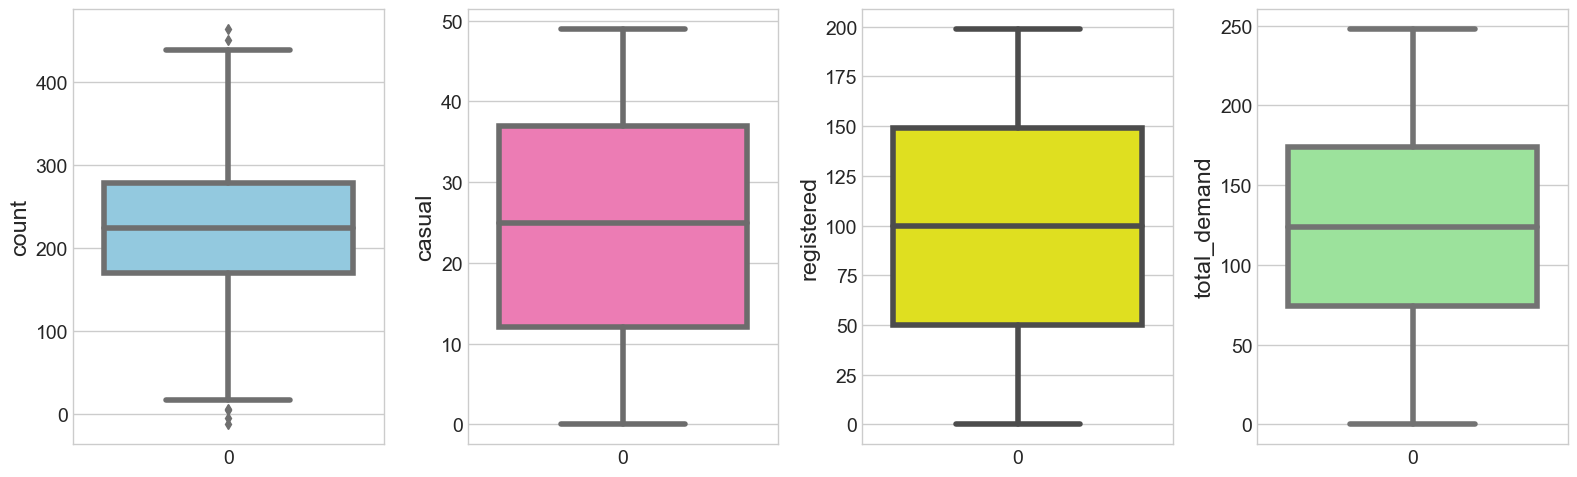

In [63]:
# Setting up the 1 row, 4 column structure as per your reference
plt.subplots(1, 4, figsize=(16, 5))

# Subplot 1: Total Count (The main target)
plt.subplot(141)
sns.boxplot(df['count'], color='skyblue')
plt.ylabel('count')

# Subplot 2: Casual Riders (Highly sensitive)
plt.subplot(142)
sns.boxplot(df['casual'], color='hotpink')
plt.ylabel('casual')

# Subplot 3: Registered Riders (Stable commuters)
plt.subplot(143)
sns.boxplot(df['registered'], color='yellow')
plt.ylabel('registered')

# Subplot 4: Total Demand (Processed Feature)
plt.subplot(144)
sns.boxplot(df['total_demand'], color='lightgreen')
plt.ylabel('total_demand')

plt.tight_layout()
plt.show()

### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

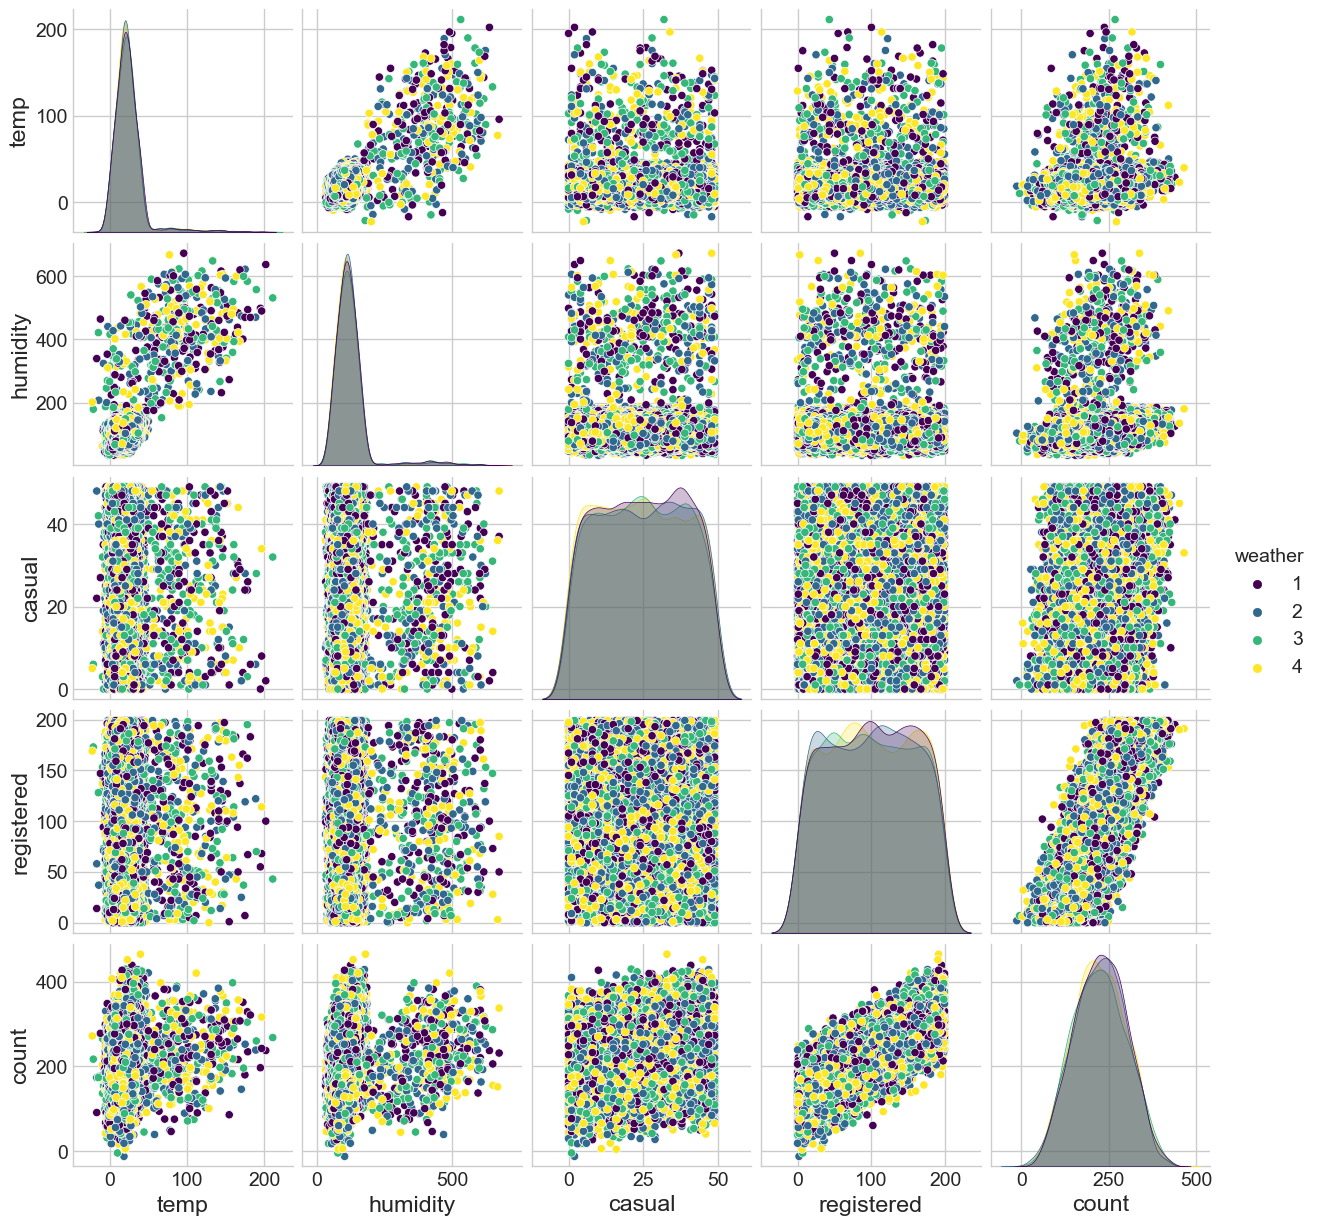

In [64]:
# Selecting relevant numerical columns for the bike project
cols = ['temp', 'humidity', 'casual', 'registered', 'count']

# Using 'weather' as the hue for bike demand context
sns.pairplot(df[cols + ['weather']], hue='weather', palette='viridis', diag_kind='kde')
plt.show()

### Insights
From the above plot it is clear that all the scores increase linearly with each other.

### 5. CONCLUSIONS
Environmental & Demographic Impact: Bike demand is significantly influenced by weather conditions and seasonal timing, much like student performance is tied to their background and resources.

User Segmentation: Just as females were found to lead in pass percentages in the student study, Registered Users in this dataset represent the "top-scorers," providing the most consistent and highest volume of rides across all time frames.

Variable Correlation: Demand is not strictly tied to a single factor; rather, it is a multivariate result of temperature, humidity, and whether it is a working day or holiday.

Operational Benefits: While a single factor like a "test preparation course" might have varied results in academics, Clear Weather Conditions (Category 1) act as the primary "benefitial" driver for peak demand in the bike-sharing ecosystem.